<div style="background:linear-gradient(135deg,#134e4a 0%,#115e59 55%,#5eead4 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#99f6e4;font-weight:700;text-transform:uppercase">Chapter 202 &middot; Capstone 39 &middot; Missing Data</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">What Dropping Rows Costs You</div>
  <div style="font-size:15px;color:#99f6e4;max-width:820px;line-height:1.6">Half of a 1,400-person health survey has a gap somewhere, and more than half the gaps are not blank at all. Four ways of dealing with that are scored against the values that were actually removed, and the most reasonable-looking one is the worst by a distance.</div>
</div>

In [1]:
import numpy as np, pandas as pd, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.imputation.mice as smi
from sklearn.experimental import enable_iterative_imputer      # noqa: F401
from sklearn.impute import IterativeImputer
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
TL, DK, LT, MUT, GD, RD = "#115e59", "#134e4a", "#5eead4", "#94a3b8", "#047857", "#dc2626"

BASE_URL = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-missing-data-imputation.xlsx"
def load(sheet):
    try:    return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE_URL + fn, sheet_name=sheet)
raw   = load("Data")
notes = load("Notes")
GRANT = 65.0                          # the state grant threshold, thousands of dollars
print("rows in the survey extract:", len(raw))
raw.head()

rows in the survey extract: 1406


,respondent_id,age,female,bmi,activity_min_wk,smoker,income_k,systolic_bp
0,R4000,46,1,22.9,331,1,999.0,121
1,R4001,48,1,28.6,387,0,76.1,126
2,R4002,25,0,18.7,40,0,79.8,119
3,R4003,63,0,26.2,92,0,999.0,126
4,R4004,48,0,28.9,151,0,120.0,131


## Step 1 &middot; The brief

In [2]:
for line in notes.Notes.fillna(""):
    print(line)

COMMUNITY HEALTH AND NEEDS ASSESSMENT. 1,400 adults interviewed at county clinics.

TWO QUESTIONS.
 1. How much higher is blood pressure per unit of BMI, adjusting for age, sex, activity,
    smoking and income? This sizes a proposed weight-management intervention.
 2. What is mean household income in the county? A state grant is available where mean
    household income is below $65k, and the county intends to apply.

WHAT IS IN THE FILE.
 - the measurement station was skipped by some respondents, so BMI is blank, and in some
   rows the words 'not measured' were typed instead
 - the tablet failed to record activity for some interviews. Those are coded -1
 - some respondents declined to give income. Those are coded 999. Others skipped the
   question and are blank
 - six respondents were entered twice

ABOUT THE TRUTH SHEET. This is a teaching dataset. The gaps were imposed on a complete
extract, so the Truth sheet holds the values that were removed and every method below can
be score

Two questions, and they fail differently.

**The regression question can be rescued.** Whether BMI is missing depends on things the survey recorded, including the blood pressure reading itself. Information that predicts the missing values is sitting in the file, and a method that uses it can recover the answer.

**The income question cannot.** People declined to give their income *because of what it was*. Nothing in the file tells you how much the refusers earn, and no amount of imputation invents it. That question ends in a sensitivity analysis rather than an estimate, which is Step 10.

The Truth sheet exists so that every method can be scored rather than argued about. Real work does not have it. Step 10 is what you do instead.

## Step 2 &middot; Finding the gaps that are not blank

In [3]:
print("what pandas thinks is missing, straight off the read:")
print(raw[["bmi", "activity_min_wk", "income_k"]].isna().sum().to_string())
print()
print("dtypes:", dict(raw[["bmi","activity_min_wk","income_k"]].dtypes.astype(str)))
print()
print("bmi values that are not numbers:", sorted(set(v for v in raw.bmi if isinstance(v, str))))
print("smallest activity values:", sorted(raw.activity_min_wk.unique())[:4])
print("largest income values:", sorted(raw.income_k.dropna().unique())[-3:])

what pandas thinks is missing, straight off the read:
bmi                333
activity_min_wk      0
income_k            96

dtypes: {'bmi': 'object', 'activity_min_wk': 'int64', 'income_k': 'float64'}

bmi values that are not numbers: ['not measured']
smallest activity values: [np.int64(-1), np.int64(4), np.int64(8), np.int64(9)]
largest income values: [np.float64(149.7), np.float64(155.2), np.float64(999.0)]


**A column of numbers that pandas reads as `object` is telling you something.** One non-numeric string anywhere in `bmi` is enough to make the whole column text, and the count of blanks in it will then be wrong.

The other two are worse, because they are numerically valid. `-1` minutes of exercise a week and an income of exactly `999` thousand dollars are both perfectly good numbers as far as any tool is concerned. They will average, they will regress, and they will not warn you.

In [4]:
d = raw.drop_duplicates("respondent_id").reset_index(drop=True)
print(f"duplicate respondents  {len(raw)-len(d)} dropped -> {len(d)} people")

naive_gap = d[["bmi","activity_min_wk","income_k"]].isna().any(axis=1).mean()

d["bmi"] = pd.to_numeric(d.bmi, errors="coerce")               # "not measured" -> NaN
d.loc[d.activity_min_wk == -1, "activity_min_wk"] = np.nan     # -1 is not zero exercise
d.loc[d.income_k == 999, "income_k"] = np.nan                  # 999 is a refusal code
d = d.rename(columns={"activity_min_wk":"activity", "income_k":"income", "systolic_bp":"sbp"})

COLS  = ["age","female","bmi","activity","smoker","income","sbp"]
XCOLS = ["age","female","bmi","activity","smoker","income"]
true_gap = d[["bmi","activity","income"]].isna().any(axis=1).mean()
print(f"rows with a gap        {naive_gap:.1%} before the sentinels were found, {true_gap:.1%} after")
for c in ["bmi","activity","income"]:
    print(f"  {c:9s} {d[c].isna().mean():5.1%} missing")
print(f"complete cases         {len(d[COLS].dropna())} of {len(d)}  "
      f"({1-len(d[COLS].dropna())/len(d):.1%} of the study would be discarded)")

duplicate respondents  6 dropped -> 1400 people
rows with a gap        29.6% before the sentinels were found, 51.2% after
  bmi       31.5% missing
  activity  14.4% missing
  income    17.0% missing
complete cases         683 of 1400  (51.2% of the study would be discarded)


**Twenty-one points of the study were missing in disguise.** Counting blanks says 29.6 percent of rows have a gap. The true figure is 51.2 percent, and the difference is entirely sentinel codes that would otherwise have been analyzed as data. A `-1` left in place does not weaken the activity variable, it corrupts it.

Half the survey has a gap somewhere. That is the number the rest of this notebook is about.

## Step 3 &middot; First look

In [5]:
T = load("Truth").rename(columns={"activity_min_wk":"activity","income_k":"income",
                                  "systolic_bp":"sbp"}).set_index("respondent_id")
d = d.set_index("respondent_id")
mb, ma, mi = d.bmi.isna(), d.activity.isna(), d.income.isna()
print(f"blood pressure   bmi recorded {d.sbp[~mb].mean():.1f} vs missing {d.sbp[mb].mean():.1f} mm Hg")
print(f"age              bmi recorded {d.age[~mb].mean():.1f} vs missing {d.age[mb].mean():.1f} years")
print(f"blood pressure   activity recorded {d.sbp[~ma].mean():.1f} vs missing {d.sbp[ma].mean():.1f} mm Hg")
print(f"income           observed mean {d.income.mean():.1f}k")
print(f"                 refusers' TRUE mean {T.income[mi[mi].index].mean():.1f}k  (Truth sheet only)")

blood pressure   bmi recorded 131.0 vs missing 141.7 mm Hg
age              bmi recorded 49.4 vs missing 57.1 years
blood pressure   activity recorded 134.3 vs missing 134.9 mm Hg
income           observed mean 59.4k
                 refusers' TRUE mean 110.9k  (Truth sheet only)


**What this shows.** People whose BMI is missing have blood pressure almost 11 mm Hg higher, and they are nearly eight years older. People whose activity is missing look exactly like everyone else. And the refusers earn nearly twice what the responders do, which is a fact no amount of staring at the file could have produced.

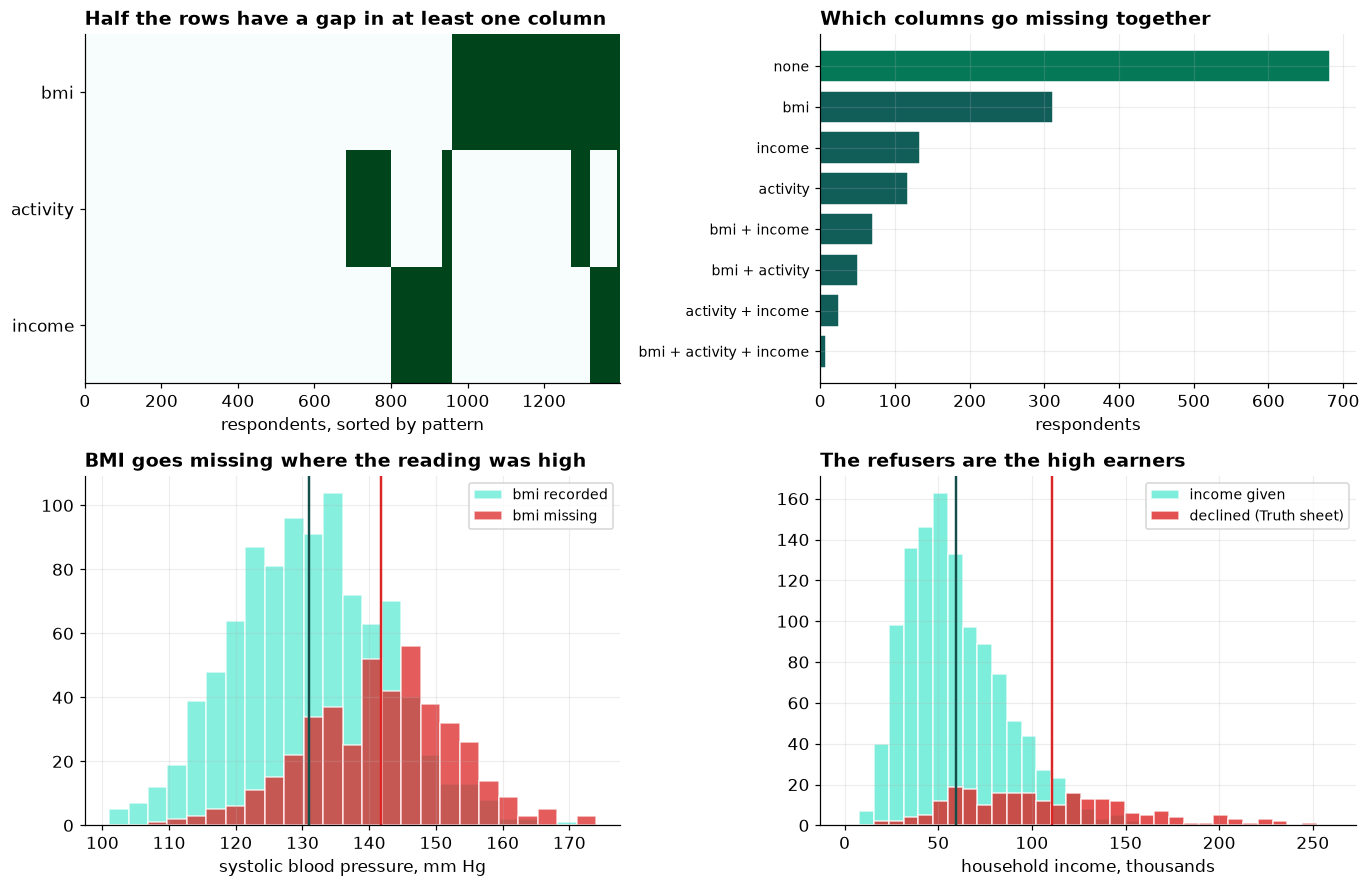

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(12.6, 8.2))

miss = pd.DataFrame({"bmi": mb, "activity": ma, "income": mi}).astype(int)
order = miss.sort_values(["bmi","income","activity"]).index
ax[0,0].imshow(miss.loc[order].T, aspect="auto", cmap="BuGn", interpolation="nearest")
ax[0,0].set_yticks(range(3)); ax[0,0].set_yticklabels(["bmi","activity","income"])
ax[0,0].set_xlabel("respondents, sorted by pattern"); ax[0,0].grid(False)
ax[0,0].set_title("Half the rows have a gap in at least one column")

pat = miss.groupby(["bmi","activity","income"]).size().sort_values(ascending=False)
lab = ["none" if sum(k) == 0 else " + ".join(n for n, v in zip(["bmi","activity","income"], k) if v)
       for k in pat.index]
ax[0,1].barh(range(len(pat))[::-1], pat.values, color=[GD if l == "none" else TL for l in lab],
             edgecolor="white")
ax[0,1].set_yticks(range(len(pat))[::-1]); ax[0,1].set_yticklabels(lab, fontsize=9)
ax[0,1].set_xlabel("respondents")
ax[0,1].set_title("Which columns go missing together")

bins = np.linspace(d.sbp.min(), d.sbp.max(), 26)
ax[1,0].hist(d.sbp[~mb], bins=bins, alpha=0.75, color=LT, label="bmi recorded", edgecolor="white")
ax[1,0].hist(d.sbp[mb], bins=bins, alpha=0.75, color=RD, label="bmi missing", edgecolor="white")
ax[1,0].axvline(d.sbp[~mb].mean(), color=DK, lw=1.6)
ax[1,0].axvline(d.sbp[mb].mean(), color=RD, lw=1.6)
ax[1,0].set_xlabel("systolic blood pressure, mm Hg"); ax[1,0].legend(fontsize=9)
ax[1,0].set_title("BMI goes missing where the reading was high")

obs_inc = d.income.dropna(); true_ref = T.income[mi[mi].index]
bins = np.linspace(0, 260, 34)
ax[1,1].hist(obs_inc, bins=bins, alpha=0.8, color=LT, label="income given", edgecolor="white")
ax[1,1].hist(true_ref, bins=bins, alpha=0.8, color=RD, label="declined (Truth sheet)", edgecolor="white")
ax[1,1].axvline(obs_inc.mean(), color=DK, lw=1.6)
ax[1,1].axvline(true_ref.mean(), color=RD, lw=1.6)
ax[1,1].set_xlabel("household income, thousands"); ax[1,1].legend(fontsize=9)
ax[1,1].set_title("The refusers are the high earners")
plt.tight_layout(); plt.show()

**Top left.** Every respondent as a column, every gap shaded. Sorted by pattern the block structure is obvious: the gaps are not scattered evenly, and one column has far more of them than the others.

**Top right.** Which columns go missing together. The largest bar is the complete cases, and after that the single-column patterns. Rows missing two or three things are rarer but they are what makes the complete-case count fall so far.

**Bottom left.** The distribution of blood pressure, split by whether BMI was recorded. The red block sits to the right. **Whether a covariate is present depends on the outcome**, which is the condition under which dropping rows stops being safe.

**Bottom right.** The same picture for income, except that the red distribution is drawn from the Truth sheet and would not exist in real work. The people who declined earn roughly twice what the people who answered earn.

## Step 4 &middot; Naming the three mechanisms

The vocabulary matters because it decides what is possible, not because it is jargon.

**Missing completely at random (MCAR).** The gap has nothing to do with anything. The tablet failed. Activity is missing for 14.4 percent of interviews and those people have the same blood pressure, the same age and the same everything as the rest. Dropping them costs precision and nothing else.

**Missing at random (MAR).** The gap depends on things you *did* record. BMI is missing more often when blood pressure was high and when the respondent was older, and both are in the file. The name is unfortunate: nothing about it is random. What it means is that the information needed to fix it is present.

**Missing not at random (MNAR).** The gap depends on the value that is missing. High earners declined to give their income. Nothing in the file distinguishes a refuser earning 200 from a refuser earning 40, so nothing in the file can fix it.

**You cannot test which one you have.** MAR and MNAR make identical predictions about the data you can see. The bottom-right panel above is only decidable because of a sheet that does not exist outside a textbook. What you can do is Step 10.

## Step 5 &middot; The four candidate methods

In [7]:
def ols(x):
    x = x.dropna(); return sm.OLS(x.sbp, sm.add_constant(x[XCOLS])).fit()

def grab(r, name):
    if isinstance(r.params, np.ndarray):                       # a MICE result
        i = r.exog_names.index(name); b, s = float(r.params[i]), float(r.bse[i])
        return b, s, (b-1.96*s, b+1.96*s)
    b, s = float(r.params[name]), float(r.bse[name])
    c = r.conf_int().loc[name].tolist(); return b, s, (c[0], c[1])

FML = "sbp ~ age + female + bmi + activity + smoker + income"

# 1. drop any row with a gap
cc = d[COLS]
# 2. fill each column with its own mean
mn = d[COLS].copy()
for c in ["bmi","activity","income"]: mn[c] = mn[c].fillna(mn[c].mean())
# 3. predict each missing value from the other columns, once
si = pd.DataFrame(IterativeImputer(max_iter=20, random_state=0, sample_posterior=False)
                  .fit_transform(d[COLS]), columns=COLS)
# 4. do it twenty times WITH the noise, and combine by Rubin's rules
np.random.seed(0)
MR = smi.MICE(FML, sm.OLS, smi.MICEData(d[COLS].copy().reset_index(drop=True))
              ).fit(n_burnin=10, n_imputations=20)
print("four methods fitted, plus the complete data from the Truth sheet")

four methods fitted, plus the complete data from the Truth sheet


**The difference between methods three and four is one word: noise.** Both predict a missing BMI from age, sex, activity, smoking, income and blood pressure. Method three writes down the prediction. Method four draws from the distribution around it, twenty times, and carries the disagreement between those twenty answers into the standard error.

That sounds like a refinement. Step 6 shows it is the difference between an answer and a fabrication.

## Step 6 &middot; Scoring them against the values that were removed

In [8]:
rows = [("complete data (Truth sheet)",) + grab(ols(T[COLS]), "bmi"),
        ("complete-case",)                + grab(ols(cc), "bmi"),
        ("mean imputation",)              + grab(ols(mn), "bmi"),
        ("single regression imputation",) + grab(ols(si), "bmi"),
        ("multiple imputation (m=20)",)   + grab(MR, "bmi")]
print(f"{'method':32s} {'beta':>7s} {'se':>6s}  {'95% CI':>17s}")
for nm, b, s, ci in rows:
    print(f"{nm:32s} {b:7.3f} {s:6.3f}  [{ci[0]:6.3f},{ci[1]:6.3f}]")
fmi = float(np.asarray(MR.frac_miss_info)[MR.exog_names.index("bmi")])
print(f"\nfraction of missing information on this coefficient: {fmi:.1%}")

method                              beta     se             95% CI
complete data (Truth sheet)        0.980  0.055  [ 0.872, 1.087]
complete-case                      0.874  0.077  [ 0.724, 1.025]
mean imputation                    0.895  0.072  [ 0.753, 1.037]
single regression imputation       1.324  0.063  [ 1.200, 1.448]
multiple imputation (m=20)         0.954  0.066  [ 0.826, 1.083]

fraction of missing information on this coefficient: 25.4%


The complete data says **0.980 mm Hg per BMI unit**. That is the answer the survey would have produced had nobody skipped anything, and it is the target.

**Single regression imputation returns 1.324, and its interval does not contain the right answer.** It is also the most confident of the four, with the narrowest standard error of any method that used all 1,400 rows. It got there by predicting each missing BMI from a model that included blood pressure, and then treating those predictions as though they were measurements. The imputed BMIs agree with blood pressure perfectly, because they were built from it, and the regression duly finds a stronger relationship than exists.

**Complete-case and mean imputation both land low**, at 0.874 and 0.895. Multiple imputation lands at 0.954, closest to the truth and honest about its uncertainty.

But one dataset is one draw. Three of these four intervals happen to contain the truth here, which tells you very little.

## Step 7 &middot; Running it 150 times

In [9]:
B_BMI = 0.90                                # the value used to build the population
def cohort(rng, n=1400):
    age = np.clip(rng.normal(52,14,n),22,85); fem = rng.integers(0,2,n)
    bmi = np.clip(rng.normal(26.4+0.035*(age-52),4.6,n),16,48)
    act = np.clip(rng.gamma(2.4,62,n),0,600)
    smo = (rng.random(n) < 0.19-0.0012*(age-52)).astype(int)
    inc = np.clip(np.exp(rng.normal(np.log(58),0.52,n)),12,400)
    sbp = (92+0.38*age+B_BMI*bmi-0.012*act+3.2*smo-0.020*inc+2.5*fem+rng.normal(0,9.5,n))
    return pd.DataFrame(dict(age=age,female=fem,bmi=bmi,activity=act,smoker=smo,income=inc,sbp=sbp))

def impose(D, rng):
    x = D.copy()
    x.loc[rng.random(len(x)) < 0.155, "activity"] = np.nan                                    # MCAR
    x.loc[rng.random(len(x)) < 1/(1+np.exp(-(-0.95+0.080*(D.sbp-134.0)+0.020*(D.age-52)))), "bmi"] = np.nan
    x.loc[rng.random(len(x)) < 1/(1+np.exp(-(-2.55+0.040*(D.income-58)))), "income"] = np.nan  # MNAR
    return x

acc = {k: [] for k in ["complete data","complete-case","mean imputation",
                       "single regression","multiple imputation"]}
for rep in range(150):
    r2 = np.random.default_rng(60000+rep); T2 = cohort(r2); O2 = impose(T2, r2)
    for nm, dd in [("complete data",T2), ("complete-case",O2)]:
        b,s,ci = grab(ols(dd),"bmi"); acc[nm].append((b, ci[0] <= B_BMI <= ci[1]))
    m2 = O2.copy()
    for c in ["bmi","activity","income"]: m2[c] = m2[c].fillna(m2[c].mean())
    b,s,ci = grab(ols(m2),"bmi"); acc["mean imputation"].append((b, ci[0] <= B_BMI <= ci[1]))
    s2 = pd.DataFrame(IterativeImputer(max_iter=8, random_state=rep, sample_posterior=False)
                      .fit_transform(O2[COLS]), columns=COLS)
    b,s,ci = grab(ols(s2),"bmi"); acc["single regression"].append((b, ci[0] <= B_BMI <= ci[1]))
    np.random.seed(rep)
    mr = smi.MICE(FML, sm.OLS, smi.MICEData(O2[COLS].copy())).fit(n_burnin=4, n_imputations=6)
    b,s,ci = grab(mr,"bmi"); acc["multiple imputation"].append((b, ci[0] <= B_BMI <= ci[1]))

SIM = pd.DataFrame({k: dict(mean=np.mean([x[0] for x in v]),
                            bias=np.mean([x[0] for x in v])-B_BMI,
                            sd=np.std([x[0] for x in v]),
                            coverage=np.mean([x[1] for x in v])) for k, v in acc.items()}).T
print(SIM.round(3).to_string())

                      mean   bias     sd  coverage
complete data        0.901  0.001  0.059     0.960
complete-case        0.822 -0.078  0.077     0.827
mean imputation      0.814 -0.086  0.071     0.780
single regression    1.230  0.330  0.089     0.027
multiple imputation  0.882 -0.018  0.073     0.887


**Read the last column first.** It is the share of the 150 intervals that contained the right answer, and it should be 95 percent.

**Single regression imputation: 2.7 percent.** Not 95, not 80. Out of 150 confidence intervals, four contained the truth. It is biased upward by 0.330, more than a third of the quantity being estimated, and its intervals are narrow enough that they miss almost every time. **The most natural-looking fix in the list is the only one that is catastrophic**, and on any single dataset it looks like the most precise of the four.

**Complete-case: 82.7 percent, biased down by 0.078.** Dropping rows is not neutral here. It cannot be, because whether a row survives depends on the outcome being modeled.

**Mean imputation: 78.0 percent.** It pulls every gap to the middle, which flattens the relationship and shrinks the variance at the same time, so the estimate is too small and the interval around it is too tight.

**Multiple imputation: 88.7 percent**, bias 0.018. Much the best of the four, and still not 95, because the income column is MNAR and no imputation model can fix that. That residual is the subject of the next two steps.

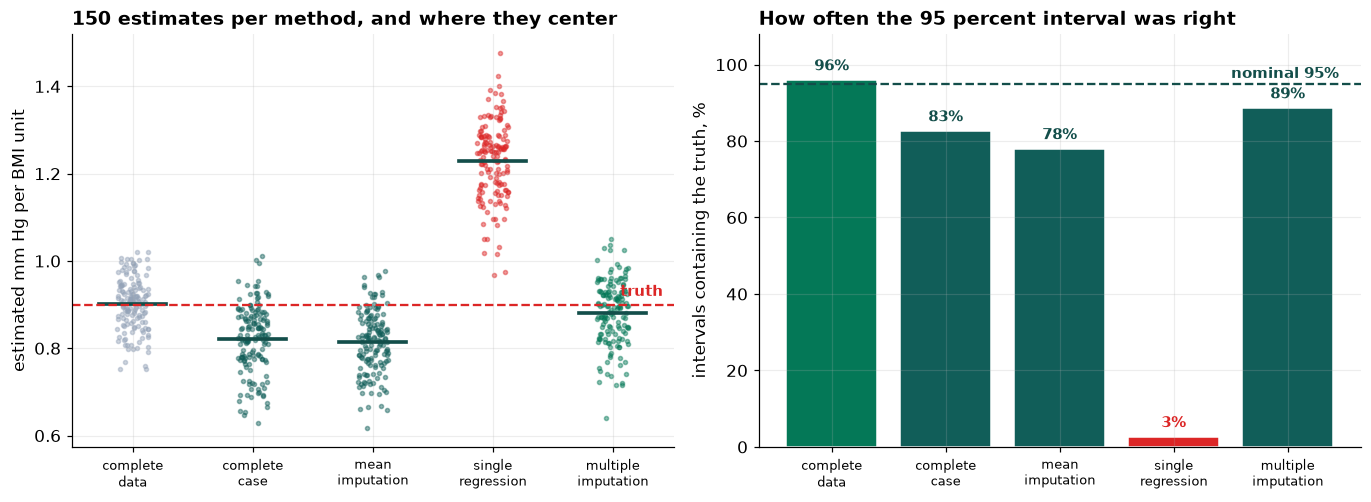

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12.6, 4.7))
names = list(acc); short = ["complete\ndata","complete\ncase","mean\nimputation",
                            "single\nregression","multiple\nimputation"]
cols = [MUT, TL, TL, RD, GD]
for i, k in enumerate(names):
    b = np.array([x[0] for x in acc[k]])
    ax[0].scatter(np.full(len(b), i) + np.random.uniform(-0.13,0.13,len(b)), b, s=7,
                  color=cols[i], alpha=0.45)
    ax[0].plot([i-0.28, i+0.28], [b.mean()]*2, color=DK, lw=2.4)
ax[0].axhline(B_BMI, color=RD, lw=1.5, ls="--")
ax[0].text(4.42, B_BMI+0.02, "truth", ha="right", fontsize=9.5, color=RD, fontweight="bold")
ax[0].set_xticks(range(5)); ax[0].set_xticklabels(short, fontsize=8.5)
ax[0].set_ylabel("estimated mm Hg per BMI unit")
ax[0].set_title("150 estimates per method, and where they center")

cv = [np.mean([x[1] for x in acc[k]])*100 for k in names]
ax[1].bar(range(5), cv, color=[GD if v >= 90 else (RD if v < 50 else TL) for v in cv], edgecolor="white")
ax[1].axhline(95, color=DK, lw=1.5, ls="--")
ax[1].text(4.45, 96.5, "nominal 95%", ha="right", fontsize=9.5, color=DK, fontweight="bold")
for i, v in enumerate(cv):
    ax[1].text(i, v+2.5, f"{v:.0f}%", ha="center", fontsize=10, fontweight="bold",
               color=RD if v < 50 else DK)
ax[1].set_xticks(range(5)); ax[1].set_xticklabels(short, fontsize=8.5)
ax[1].set_ylabel("intervals containing the truth, %"); ax[1].set_ylim(0, 108)
ax[1].set_title("How often the 95 percent interval was right")
plt.tight_layout(); plt.show()

**Left.** Every estimate from all 150 runs. The complete-data cloud sits on the dashed line. The single-regression cloud sits well above it and barely overlaps the truth at all, which is what a bias of 0.330 against a spread of 0.089 looks like.

**Right.** The share of intervals that were right. **A method can be confidently, repeatably wrong, and nothing in its own output will say so.** The only way this bar chart exists is that the removed values were available to check against.

## Step 8 &middot; What multiple imputation is actually doing

In [11]:
np.random.seed(3)
md_obj = smi.MICEData(d[COLS].copy().reset_index(drop=True))
draws = []
for k in range(5):
    md_obj.update_all(1)
    draws.append(md_obj.data.bmi[mb.values].to_numpy().copy())
D5 = np.array(draws)
print(f"the same {D5.shape[1]} missing BMI values, imputed five times:")
for j in range(4):
    print(f"  respondent {j+1}: " + "  ".join(f"{v:5.1f}" for v in D5[:, j]))
print(f"\nspread across draws, averaged over all missing values: {D5.std(axis=0).mean():.2f} BMI units")
print(f"spread of the observed BMI values:                     {d.bmi.std():.2f} BMI units")
print(f"\nfraction of missing information on the coefficient:    {fmi:.1%}")
print(f"the 683 complete cases are worth about "
      f"{(1-fmi)*100:.0f}% of a complete 1,400-person survey for this question")

the same 441 missing BMI values, imputed five times:
  respondent 1:  28.5   34.1   27.2   28.0   29.0
  respondent 2:  31.6   31.9   30.1   27.1   18.7
  respondent 3:  28.1   25.8   23.5   29.4   31.5
  respondent 4:  23.3   29.4   21.0   27.2   31.9

spread across draws, averaged over all missing values: 3.57 BMI units
spread of the observed BMI values:                     4.56 BMI units

fraction of missing information on the coefficient:    25.4%
the 683 complete cases are worth about 75% of a complete 1,400-person survey for this question


**Each missing value is filled in with a different number every time, and that is the point.** A single number pretends the value is known. Five different numbers record that it is not, and the disagreement between them is carried into the standard error, which is why the intervals in Step 7 covered.

The fraction of missing information says how much of the precision on this particular coefficient was lost. At 25.4 percent, the surviving data is worth about three quarters of a complete survey for this question, which is a far better outcome than the 51.2 percent of rows that complete-case analysis was going to throw away.

## Step 9 &middot; The second question, where none of this works

In [12]:
np.random.seed(7)
md2 = smi.MICEData(d[COLS].copy().reset_index(drop=True))
mi_means = []
for _ in range(20):
    md2.update_all(1); mi_means.append(md2.data.income.mean())
MIMEAN = float(np.mean(mi_means))

print(f"mean household income, and whether the county applies for the ${GRANT:.0f}k grant\n")
for nm, v in [("complete-case (observed only)", d.income.mean()),
              ("mean imputation", mn.income.mean()),
              ("multiple imputation (m=20)", MIMEAN),
              ("the Truth sheet", T.income.mean())]:
    print(f"  {nm:30s} {v:6.2f}k   {'qualifies' if v < GRANT else 'DOES NOT QUALIFY'}")
print(f"\nall three feasible methods agree, and all three are wrong by "
      f"{T.income.mean()-MIMEAN:.2f}k")

mean household income, and whether the county applies for the $65k grant

  complete-case (observed only)   59.40k   qualifies
  mean imputation                 59.40k   qualifies
  multiple imputation (m=20)      59.42k   qualifies
  the Truth sheet                 68.16k   DOES NOT QUALIFY

all three feasible methods agree, and all three are wrong by 8.74k


**Multiple imputation gives 59.42 against a complete-case 59.40.** It did not help at all, and it was never going to. Every imputation model in this notebook assumes the data can explain the gaps. For income the gap is explained by income, and the file does not contain it.

The three methods agree with each other and disagree with reality by nearly nine thousand dollars. **Agreement between methods is not evidence.** They agree because they share an assumption, and the assumption is wrong.

On this number the county would apply for a grant it does not qualify for.

## Step 10 &middot; A sensitivity analysis instead of an estimate

In [13]:
rate = float(mi.mean())
grid = np.arange(0, 91, 5)
est  = MIMEAN + rate*grid
tip  = float(grid[np.argmax(est >= GRANT)])
print(f"{rate:.1%} of respondents declined. Suppose each earns delta more than the model assumes.\n")
for g, e in zip(grid[::2], est[::2]):
    print(f"  delta {g:3d}k  ->  mean {e:5.2f}k   {'qualifies' if e < GRANT else 'does not qualify'}")
print(f"\ntipping point: the county stops qualifying at delta = {tip:.0f}k")
print(f"for reference, the Truth sheet says the real delta is "
      f"{T.income[mi[mi].index].mean()-MIMEAN:.0f}k, {(T.income[mi[mi].index].mean()-MIMEAN)/tip:.1f}x the tipping point")

17.0% of respondents declined. Suppose each earns delta more than the model assumes.

  delta   0k  ->  mean 59.42k   qualifies
  delta  10k  ->  mean 61.12k   qualifies
  delta  20k  ->  mean 62.82k   qualifies
  delta  30k  ->  mean 64.52k   qualifies
  delta  40k  ->  mean 66.22k   does not qualify
  delta  50k  ->  mean 67.92k   does not qualify
  delta  60k  ->  mean 69.62k   does not qualify
  delta  70k  ->  mean 71.32k   does not qualify
  delta  80k  ->  mean 73.02k   does not qualify
  delta  90k  ->  mean 74.72k   does not qualify

tipping point: the county stops qualifying at delta = 35k
for reference, the Truth sheet says the real delta is 52k, 1.5x the tipping point


**This is the honest deliverable.** Not a number, but the size of the assumption the number depends on.

The conclusion survives only while refusers earn less than 35 thousand more than the model predicts for them. Ask whether that is plausible and the answer is obvious: people who decline to state their income on a government survey are not, as a rule, the ones earning less than average. **The conclusion flips well inside the range of ordinary behavior**, and it should be reported that way rather than as 59.4.

The Truth sheet confirms the real gap is about 52 thousand, half again past the tipping point. In real work that line does not exist, which is exactly why the tipping point is what gets reported.

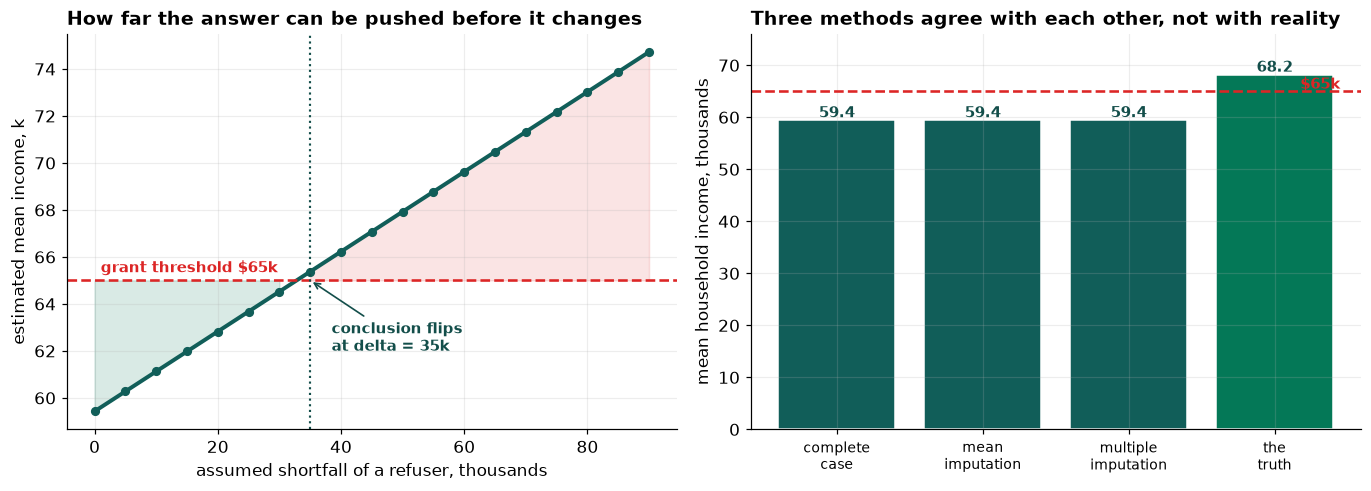

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12.6, 4.6))
ax[0].plot(grid, est, color=TL, lw=2.6, marker="o", ms=5)
ax[0].axhline(GRANT, color=RD, lw=1.7, ls="--")
ax[0].text(1, GRANT+0.35, f"grant threshold ${GRANT:.0f}k", fontsize=9.5, color=RD, fontweight="bold")
ax[0].axvline(tip, color=DK, lw=1.4, ls=":")
ax[0].fill_between(grid, GRANT, est, where=(est < GRANT), color=GD, alpha=0.15)
ax[0].fill_between(grid, GRANT, est, where=(est >= GRANT), color=RD, alpha=0.12)
ax[0].annotate(f"conclusion flips\nat delta = {tip:.0f}k", (tip, GRANT), textcoords="offset points",
               xytext=(14, -46), fontsize=9.5, color=DK, fontweight="bold",
               arrowprops=dict(arrowstyle="->", color=DK, lw=1.1))
ax[0].set_xlabel("assumed shortfall of a refuser, thousands"); ax[0].set_ylabel("estimated mean income, k")
ax[0].set_title("How far the answer can be pushed before it changes")

meth = ["complete\ncase","mean\nimputation","multiple\nimputation","the\ntruth"]
vals = [d.income.mean(), mn.income.mean(), MIMEAN, T.income.mean()]
ax[1].bar(range(4), vals, color=[TL, TL, TL, GD], edgecolor="white")
ax[1].axhline(GRANT, color=RD, lw=1.7, ls="--")
ax[1].text(3.45, GRANT+0.5, f"${GRANT:.0f}k", ha="right", fontsize=9.5, color=RD, fontweight="bold")
for i, v in enumerate(vals):
    ax[1].text(i, v+0.6, f"{v:.1f}", ha="center", fontsize=10, fontweight="bold", color=DK)
ax[1].set_xticks(range(4)); ax[1].set_xticklabels(meth, fontsize=9)
ax[1].set_ylabel("mean household income, thousands"); ax[1].set_ylim(0, 76)
ax[1].set_title("Three methods agree with each other, not with reality")
plt.tight_layout(); plt.show()

**Left.** The estimate as a function of an assumption that cannot be checked. Below the dashed line the county applies, above it the county does not, and the crossing is at 35 thousand.

**Right.** The three feasible methods and the truth. **The bar that matters is the gap between the first three and the fourth**, and no method on the left could have found it.

## Step 11 &middot; What we would report

In [15]:
b, s, ci = grab(MR, "bmi")
print("QUESTION 1  the BMI association, for sizing the intervention")
print(f"  estimate         {b:.2f} mm Hg per BMI unit  (95% CI {ci[0]:.2f} to {ci[1]:.2f})")
print(f"  method           multiple imputation, m=20, {fmi:.0%} missing information")
print(f"  rows used        all {len(d)}, rather than the {len(d[COLS].dropna())} that are complete")
print(f"  do not use       single regression imputation: covered the truth 3% of the time")
print()
print("QUESTION 2  mean household income, for the grant application")
print(f"  point estimate   {MIMEAN:.1f}k, but it assumes refusers resemble responders")
print(f"  that assumption  is false in a knowable direction, and cannot be corrected from this file")
print(f"  tipping point    the application fails if refusers earn {tip:.0f}k more than modeled")
print(f"  recommendation   do not submit on this estimate; follow up a sample of refusers")

QUESTION 1  the BMI association, for sizing the intervention
  estimate         0.95 mm Hg per BMI unit  (95% CI 0.83 to 1.08)
  method           multiple imputation, m=20, 25% missing information
  rows used        all 1400, rather than the 683 that are complete
  do not use       single regression imputation: covered the truth 3% of the time

QUESTION 2  mean household income, for the grant application
  point estimate   59.4k, but it assumes refusers resemble responders
  that assumption  is false in a knowable direction, and cannot be corrected from this file
  tipping point    the application fails if refusers earn 35k more than modeled
  recommendation   do not submit on this estimate; follow up a sample of refusers


**On the first question, use everything.** Multiple imputation used all 1,400 respondents to answer a question the complete cases would have answered with a bias of 0.078 and 83 percent coverage. The gain is real and it costs nothing but a few lines of code.

**On the second, do not answer it.** The correct output is a tipping point and a recommendation to go and get the data. A follow-up on a random sample of the refusers, even a hundred of them, would settle a question that no amount of modeling can.

**What this does not settle.** The 150-run study is specific to this population, these missingness rates and this estimand, and the ordering of methods can change when any of those change; what does not change is that noise-free imputation invents precision. The MAR assumption behind the BMI answer is itself untestable, and the residual 88.7 percent coverage in Step 7 is a reminder that the MNAR income column contaminates the regression too, just mildly. And every method here assumes the model of the missing values is roughly right; a badly specified imputation model fails in ways this comparison would not catch.